In [137]:
!pip install catboost


[notice] A new release of pip is available: 23.2.1 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [138]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.metrics import r2_score, mean_absolute_error as mae
from sklearn.neighbors import KNeighborsRegressor
from catboost import CatBoostRegressor, Pool
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor

def smape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    smape_value = 100 * np.mean(numerator / denominator)
    return smape_value

In [139]:
df = pd.read_csv('data.csv')
df

,dates,SKU,price_per_sku,num_purchases,week_num,year,discount,fincode,ui1_code,ui2_code,ui3_code,vendor,brand_code,creation_date,expiration_date,week_num_expiration,year_expiration,week_num_creation,year_creation,margin
0,2018-01-17,60870,109.182,7,3,2018,1.0,15,151,15100,1510003,UEYMBB,WKXRWTP7,2018-01-17,2019-04-02 00:00:00,14,2019,3,2018,21.836400
1,2018-01-18,60870,109.182,7,3,2018,1.0,15,151,15100,1510003,UEYMBB,WKXRWTP7,2018-01-17,2019-04-02 00:00:00,14,2019,3,2018,21.836400
2,2018-01-19,60870,109.182,8,3,2018,1.0,15,151,15100,1510003,UEYMBB,WKXRWTP7,2018-01-17,2019-04-02 00:00:00,14,2019,3,2018,20.016700
3,2018-01-21,60870,109.182,7,3,2018,1.0,15,151,15100,1510003,UEYMBB,WKXRWTP7,2018-01-17,2019-04-02 00:00:00,14,2019,3,2018,21.836400
4,2018-01-22,60870,109.315,8,4,2018,1.0,15,151,15100,1510003,UEYMBB,WKXRWTP7,2018-01-17,2019-04-02 00:00:00,14,2019,3,2018,20.041083
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6694,2019-12-23,38767,74.536,7,52,2019,1.0,15,151,15100,1510002,4HJSP5,79VL731U,2018-02-08,2200-01-01 00:00:00,1,2200,6,2018,14.907200
6695,2019-12-23,80631,92.257,5,52,2019,1.0,15,151,15100,1510003,VWHZMG,WKXRWTP7,2019-05-12,2200-01-01 00:00:00,1,2200,19,2019,21.526633
6696,2019-12-23,84395,140.815,10,52,2019,1.0,15,151,15100,1510003,GVL335,WKXRWTP7,2018-04-12,2200-01-01 00:00:00,1,2200,15,2018,21.122250
6697,2019-12-24,10334,101.094,9,52,2019,1.0,15,151,15100,1510002,4HJSP5,79VL731U,2018-04-19,2200-01-01 00:00:00,1,2200,16,2018,16.849000


In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6699 entries, 0 to 6698
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   dates                6699 non-null   object 
 1   SKU                  6699 non-null   int64  
 2   price_per_sku        6699 non-null   float64
 3   num_purchases        6699 non-null   int64  
 4   week_num             6699 non-null   int64  
 5   year                 6699 non-null   int64  
 6   discount             6699 non-null   float64
 7   fincode              6699 non-null   object 
 8   ui1_code             6699 non-null   object 
 9   ui2_code             6699 non-null   object 
 10  ui3_code             6699 non-null   object 
 11  vendor               6699 non-null   object 
 12  brand_code           6699 non-null   object 
 13  creation_date        6699 non-null   object 
 14  expiration_date      6699 non-null   object 
 15  week_num_expiration  6699 non-null   i

In [141]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [142]:
df['dates'] = pd.to_datetime(df['dates'])
df

,dates,SKU,price_per_sku,num_purchases,week_num,year,discount,fincode,ui1_code,ui2_code,ui3_code,vendor,brand_code,creation_date,expiration_date,week_num_expiration,year_expiration,week_num_creation,year_creation,margin
0,2018-12-21,68211,164.250,11,51,2018,1.0,15,151,15100,1510002,4O4WSH,79VL731U,2018-03-06,2019-03-03 00:00:00,9,2019,10,2018,21.900000
1,2018-12-01,10334,95.606,10,48,2018,1.0,15,151,15100,1510002,4HJSP5,79VL731U,2018-04-19,2200-01-01 00:00:00,1,2200,16,2018,14.340900
2,2019-09-20,49661,160.476,8,38,2019,1.0,15,151,15100,1510003,2CI2A8,WKXRWTP7,2019-02-03,2200-01-01 00:00:00,1,2200,5,2019,29.420600
3,2019-02-14,84395,136.902,8,7,2019,1.0,15,151,15100,1510003,GVL335,WKXRWTP7,2018-04-12,2200-01-01 00:00:00,1,2200,15,2018,25.098700
4,2018-04-10,38767,64.372,9,15,2018,1.0,15,151,15100,1510002,4HJSP5,79VL731U,2018-02-08,2200-01-01 00:00:00,1,2200,6,2018,10.728667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6694,2019-04-19,83329,84.566,9,16,2019,1.0,15,151,15100,1510002,VWHZMG,79VL731U,2018-11-20,2200-01-01 00:00:00,1,2200,47,2018,14.094333
6695,2019-08-23,11050,109.520,8,34,2019,1.0,15,151,15100,1510003,CHQKSO,WKXRWTP7,2018-04-21,2200-01-01 00:00:00,1,2200,16,2018,20.078667
6696,2019-08-25,89272,123.925,8,34,2019,1.0,15,151,15100,1510003,UH2WWF,WKXRWTP7,2018-04-14,2200-01-01 00:00:00,1,2200,15,2018,22.719583
6697,2019-09-08,11050,110.962,8,36,2019,1.0,15,151,15100,1510003,CHQKSO,WKXRWTP7,2018-04-21,2200-01-01 00:00:00,1,2200,16,2018,20.343033


In [143]:
df['day'] = df['dates'].dt.day

In [144]:
df['month'] = df['dates'].dt.month

In [145]:
df['year'] = df['dates'].dt.year

In [146]:
df

,dates,SKU,price_per_sku,num_purchases,week_num,year,discount,fincode,ui1_code,ui2_code,...,brand_code,creation_date,expiration_date,week_num_expiration,year_expiration,week_num_creation,year_creation,margin,day,month
0,2018-12-21,68211,164.250,11,51,2018,1.0,15,151,15100,...,79VL731U,2018-03-06,2019-03-03 00:00:00,9,2019,10,2018,21.900000,21,12
1,2018-12-01,10334,95.606,10,48,2018,1.0,15,151,15100,...,79VL731U,2018-04-19,2200-01-01 00:00:00,1,2200,16,2018,14.340900,1,12
2,2019-09-20,49661,160.476,8,38,2019,1.0,15,151,15100,...,WKXRWTP7,2019-02-03,2200-01-01 00:00:00,1,2200,5,2019,29.420600,20,9
3,2019-02-14,84395,136.902,8,7,2019,1.0,15,151,15100,...,WKXRWTP7,2018-04-12,2200-01-01 00:00:00,1,2200,15,2018,25.098700,14,2
4,2018-04-10,38767,64.372,9,15,2018,1.0,15,151,15100,...,79VL731U,2018-02-08,2200-01-01 00:00:00,1,2200,6,2018,10.728667,10,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6694,2019-04-19,83329,84.566,9,16,2019,1.0,15,151,15100,...,79VL731U,2018-11-20,2200-01-01 00:00:00,1,2200,47,2018,14.094333,19,4
6695,2019-08-23,11050,109.520,8,34,2019,1.0,15,151,15100,...,WKXRWTP7,2018-04-21,2200-01-01 00:00:00,1,2200,16,2018,20.078667,23,8
6696,2019-08-25,89272,123.925,8,34,2019,1.0,15,151,15100,...,WKXRWTP7,2018-04-14,2200-01-01 00:00:00,1,2200,15,2018,22.719583,25,8
6697,2019-09-08,11050,110.962,8,36,2019,1.0,15,151,15100,...,WKXRWTP7,2018-04-21,2200-01-01 00:00:00,1,2200,16,2018,20.343033,8,9


In [147]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6699 entries, 0 to 6698
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   dates                6699 non-null   datetime64[ns]
 1   SKU                  6699 non-null   int64         
 2   price_per_sku        6699 non-null   float64       
 3   num_purchases        6699 non-null   int64         
 4   week_num             6699 non-null   int64         
 5   year                 6699 non-null   int32         
 6   discount             6699 non-null   float64       
 7   fincode              6699 non-null   object        
 8   ui1_code             6699 non-null   object        
 9   ui2_code             6699 non-null   object        
 10  ui3_code             6699 non-null   object        
 11  vendor               6699 non-null   object        
 12  brand_code           6699 non-null   object        
 13  creation_date        6699 non-nul

In [148]:
df.drop(['dates', 'creation_date', 'expiration_date', 'margin'], axis=1, inplace=True)

In [149]:
df

,SKU,price_per_sku,num_purchases,week_num,year,discount,fincode,ui1_code,ui2_code,ui3_code,vendor,brand_code,week_num_expiration,year_expiration,week_num_creation,year_creation,day,month
0,68211,164.250,11,51,2018,1.0,15,151,15100,1510002,4O4WSH,79VL731U,9,2019,10,2018,21,12
1,10334,95.606,10,48,2018,1.0,15,151,15100,1510002,4HJSP5,79VL731U,1,2200,16,2018,1,12
2,49661,160.476,8,38,2019,1.0,15,151,15100,1510003,2CI2A8,WKXRWTP7,1,2200,5,2019,20,9
3,84395,136.902,8,7,2019,1.0,15,151,15100,1510003,GVL335,WKXRWTP7,1,2200,15,2018,14,2
4,38767,64.372,9,15,2018,1.0,15,151,15100,1510002,4HJSP5,79VL731U,1,2200,6,2018,10,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6694,83329,84.566,9,16,2019,1.0,15,151,15100,1510002,VWHZMG,79VL731U,1,2200,47,2018,19,4
6695,11050,109.520,8,34,2019,1.0,15,151,15100,1510003,CHQKSO,WKXRWTP7,1,2200,16,2018,23,8
6696,89272,123.925,8,34,2019,1.0,15,151,15100,1510003,UH2WWF,WKXRWTP7,1,2200,15,2018,25,8
6697,11050,110.962,8,36,2019,1.0,15,151,15100,1510003,CHQKSO,WKXRWTP7,1,2200,16,2018,8,9


In [150]:
train = df.head(6000)
test = df.tail(6699)

In [151]:
cat_features_cb = ['SKU', 'fincode', 'ui1_code', 'ui2_code', 'ui3_code', 'vendor', 'brand_code']
cat_features = ['fincode', 'ui1_code', 'ui2_code', 'ui3_code', 'vendor', 'brand_code']

In [152]:
train_lr = train.copy()
test_lr = test.copy()

In [153]:
for col in cat_features:
    le = LabelEncoder()
    train_lr[col] = le.fit_transform(train_lr[col])
    test_lr[col] = le.transform(test_lr[col])

In [154]:
train_lr

,SKU,price_per_sku,num_purchases,week_num,year,discount,fincode,ui1_code,ui2_code,ui3_code,vendor,brand_code,week_num_expiration,year_expiration,week_num_creation,year_creation,day,month
0,68211,164.250,11,51,2018,1.0,0,0,0,0,2,1,9,2019,10,2018,21,12
1,10334,95.606,10,48,2018,1.0,0,0,0,0,1,1,1,2200,16,2018,1,12
2,49661,160.476,8,38,2019,1.0,0,0,0,1,0,2,1,2200,5,2019,20,9
3,84395,136.902,8,7,2019,1.0,0,0,0,1,9,2,1,2200,15,2018,14,2
4,38767,64.372,9,15,2018,1.0,0,0,0,0,1,1,1,2200,6,2018,10,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,83329,81.948,10,48,2018,1.0,0,0,0,0,15,1,1,2200,47,2018,29,11
5996,10334,98.826,9,35,2019,1.0,0,0,0,0,1,1,1,2200,16,2018,1,9
5997,17812,73.488,3,5,2019,1.0,0,0,0,0,2,1,1,2200,38,2018,2,2
5998,84395,134.018,10,42,2018,1.0,0,0,0,1,9,2,1,2200,15,2018,18,10


In [155]:
train_lr.ui1_code.value_counts()

ui1_code
0    5852
1     148
Name: count, dtype: int64

In [156]:
X_train = train_lr.drop('num_purchases', axis=1)
y_train = train_lr.num_purchases

X_test = test_lr.drop('num_purchases', axis=1)
y_test = test_lr.num_purchases

In [157]:
lr = LinearRegression()

In [158]:
lr.fit(X_train, y_train)

LinearRegression()

In [159]:
y_pred = lr.predict(X_test).round()

In [160]:
smape(y_test, y_pred)

22.86073583271587

In [161]:
knn = KNeighborsRegressor()
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test).round()
smape(y_test, y_pred)

8.065205766583345

In [162]:
ridge = Ridge(2)

In [163]:
ridge.fit(X_train, y_train)

Ridge(alpha=2)

In [164]:
y_pred = ridge.predict(X_test).round()

In [165]:
smape(y_test, y_pred)

22.997073681932893

In [166]:
train_cb = train.copy()
test_cb = test.copy()

In [167]:
X_train = train_cb.drop('num_purchases', axis=1)
y_train = train_cb.num_purchases

X_test = test_cb.drop('num_purchases', axis=1)
y_test = test_cb.num_purchases

In [168]:
train_pool = Pool(X_train, cat_features=cat_features_cb, label=y_train)
test_pool = Pool(X_test, cat_features=cat_features_cb, label=y_test)

In [169]:
cb = CatBoostRegressor(cat_features=cat_features_cb, thread_count=-1)

In [170]:
cb.fit(train_pool)

Learning rate set to 0.054341
0:	learn: 2.3257421	total: 29ms	remaining: 29s
1:	learn: 2.2321403	total: 66.1ms	remaining: 33s
2:	learn: 2.1451115	total: 100ms	remaining: 33.3s
3:	learn: 2.0666665	total: 135ms	remaining: 33.7s
4:	learn: 1.9870399	total: 176ms	remaining: 34.9s
5:	learn: 1.9128046	total: 211ms	remaining: 34.9s
6:	learn: 1.8405910	total: 248ms	remaining: 35.2s
7:	learn: 1.7773493	total: 294ms	remaining: 36.5s
8:	learn: 1.7196727	total: 330ms	remaining: 36.3s
9:	learn: 1.6613772	total: 365ms	remaining: 36.1s
10:	learn: 1.6089439	total: 399ms	remaining: 35.9s
11:	learn: 1.5571042	total: 433ms	remaining: 35.6s
12:	learn: 1.5113434	total: 466ms	remaining: 35.4s
13:	learn: 1.4690317	total: 499ms	remaining: 35.1s
14:	learn: 1.4309794	total: 532ms	remaining: 35s
15:	learn: 1.3950567	total: 565ms	remaining: 34.7s
16:	learn: 1.3611846	total: 599ms	remaining: 34.7s
17:	learn: 1.3275906	total: 631ms	remaining: 34.4s
18:	learn: 1.2961194	total: 666ms	remaining: 34.4s
19:	learn: 1.2659

In [171]:
y_pred = cb.predict(test_pool).round()

In [172]:
smape(y_test, y_pred)

8.478089387272176

In [173]:
rf = RandomForestRegressor(n_jobs=-1)

In [174]:
X_train = train_lr.drop('num_purchases', axis=1)
y_train = train_lr.num_purchases

X_test = test_lr.drop('num_purchases', axis=1)
y_test = test_lr.num_purchases

In [175]:
rf.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1)

In [176]:
y_pred = rf.predict(X_test).round()

In [177]:
smape(y_test, y_pred)

2.8425915136856874

In [178]:
dtrain = xgb.DMatrix(X_train,
                     label=y_train,
                     nthread=-1,)

dtest = xgb.DMatrix(X_test,
                    y_test,
                    nthread=-1,
                    )

In [179]:
params = {
    'objective': 'reg:squarederror',
    'tree_method': 'hist', # 'gpu_hist' # Место для ускорения
    'seed': 42,
}
booster = xgb.train(params,
                    dtrain=dtrain,
                    num_boost_round=1000,
                    evals=[(dtrain, 'dtrain'), (dtest, 'dtest')],
                    early_stopping_rounds=10,
                    verbose_eval=5)

[0]	dtrain-rmse:1.87501	dtest-rmse:1.87813
[5]	dtrain-rmse:0.97664	dtest-rmse:0.98095
[10]	dtrain-rmse:0.82833	dtest-rmse:0.83543
[15]	dtrain-rmse:0.79049	dtest-rmse:0.80089
[20]	dtrain-rmse:0.76359	dtest-rmse:0.77651
[25]	dtrain-rmse:0.74107	dtest-rmse:0.75581
[30]	dtrain-rmse:0.72269	dtest-rmse:0.73970
[35]	dtrain-rmse:0.70512	dtest-rmse:0.72433
[40]	dtrain-rmse:0.68780	dtest-rmse:0.70876
[45]	dtrain-rmse:0.67322	dtest-rmse:0.69591
[50]	dtrain-rmse:0.66131	dtest-rmse:0.68536
[55]	dtrain-rmse:0.64806	dtest-rmse:0.67430
[60]	dtrain-rmse:0.63399	dtest-rmse:0.66263
[65]	dtrain-rmse:0.62455	dtest-rmse:0.65485
[70]	dtrain-rmse:0.61323	dtest-rmse:0.64517
[75]	dtrain-rmse:0.60548	dtest-rmse:0.63866
[80]	dtrain-rmse:0.59646	dtest-rmse:0.63120
[85]	dtrain-rmse:0.58805	dtest-rmse:0.62435
[90]	dtrain-rmse:0.57953	dtest-rmse:0.61760
[95]	dtrain-rmse:0.57218	dtest-rmse:0.61196
[100]	dtrain-rmse:0.56346	dtest-rmse:0.60492
[105]	dtrain-rmse:0.55514	dtest-rmse:0.59806
[110]	dtrain-rmse:0.54822	dtest-

In [180]:
y_pred = booster.predict(dtest).round()

In [181]:
smape(y_test, y_pred)

1.2480339046385964

In [182]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [183]:
mlp = MLPRegressor(hidden_layer_sizes=(64, 32),  # Два скрытых слоя: 64 и 32 нейрона
                   activation='relu',           # Функция активации
                   solver='adam',               # Оптимизатор
                   learning_rate_init=0.01,     # Начальная скорость обучения
                   max_iter=50,                # Количество эпох
                   random_state=42)

mlp.fit(X_train_scaled, y_train)

y_pred = mlp.predict(X_test_scaled).round()
smape(y_test, y_pred)

D:\deploy_ml_service\application\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


10.168019647557294

<Axes: title={'center': 'Feature Importance Weight'}, xlabel='F score', ylabel='Features'>

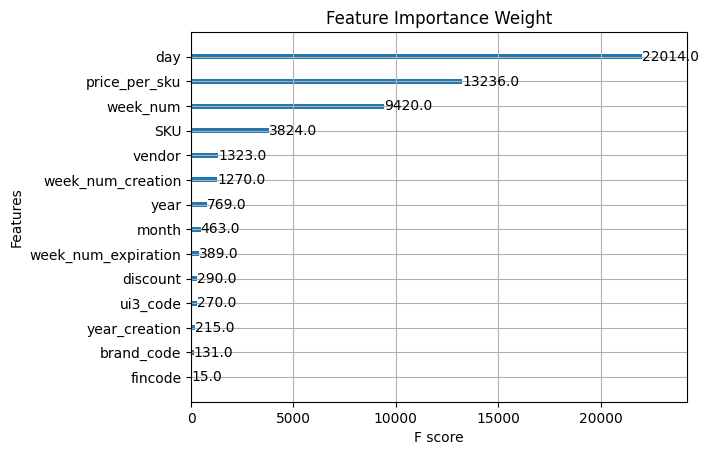

In [184]:
xgb.plot_importance(booster, title='Feature Importance Weight')

<Axes: title={'center': 'Feature Importance Gain'}, xlabel='F score', ylabel='Features'>

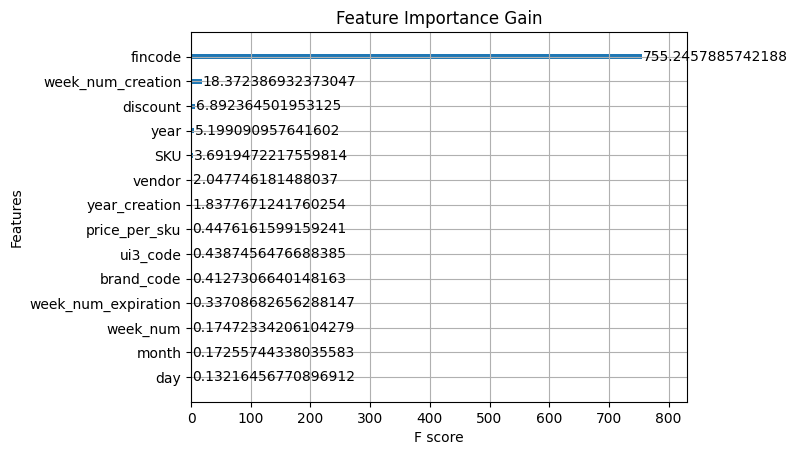

In [185]:
xgb.plot_importance(booster, importance_type='gain', title='Feature Importance Gain')

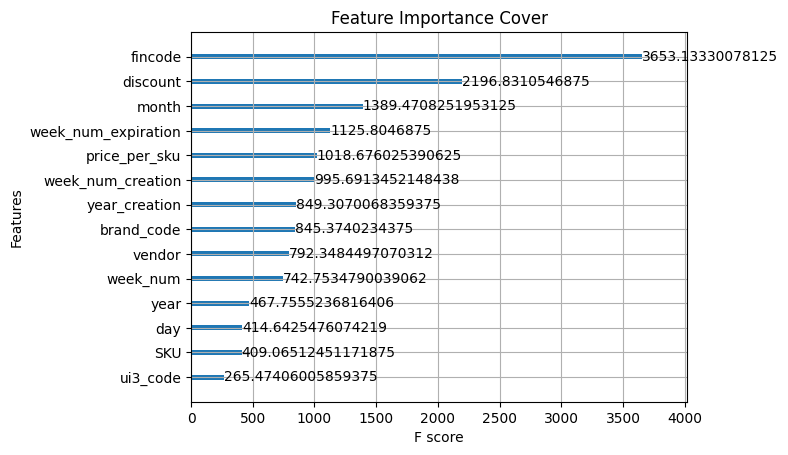

In [186]:
xgb.plot_importance(booster, importance_type='cover', title='Feature Importance Cover');

In [187]:
np.arange(-50, 51)

array([-50, -49, -48, -47, -46, -45, -44, -43, -42, -41, -40, -39, -38,
       -37, -36, -35, -34, -33, -32, -31, -30, -29, -28, -27, -26, -25,
       -24, -23, -22, -21, -20, -19, -18, -17, -16, -15, -14, -13, -12,
       -11, -10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,   1,
         2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,  14,
        15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,
        28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,
        41,  42,  43,  44,  45,  46,  47,  48,  49,  50])

In [188]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6699 entries, 0 to 6698
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   SKU                  6699 non-null   int64  
 1   price_per_sku        6699 non-null   float64
 2   num_purchases        6699 non-null   int64  
 3   week_num             6699 non-null   int64  
 4   year                 6699 non-null   int32  
 5   discount             6699 non-null   float64
 6   fincode              6699 non-null   object 
 7   ui1_code             6699 non-null   object 
 8   ui2_code             6699 non-null   object 
 9   ui3_code             6699 non-null   object 
 10  vendor               6699 non-null   object 
 11  brand_code           6699 non-null   object 
 12  week_num_expiration  6699 non-null   int64  
 13  year_expiration      6699 non-null   int64  
 14  week_num_creation    6699 non-null   int64  
 15  year_creation        6699 non-null   i

In [190]:
latest_prices = df.loc[df.groupby('SKU')['week_num'].idxmax()].reset_index(drop=True)
latest_prices

,SKU,price_per_sku,num_purchases,week_num,year,discount,fincode,ui1_code,ui2_code,ui3_code,vendor,brand_code,week_num_expiration,year_expiration,week_num_creation,year_creation,day,month
0,10334,95.641,11,52,2018,1.0,15,151,15100,1510002,4HJSP5,79VL731U,1,2200,16,2018,27,12
1,11050,106.426,9,52,2018,1.0,15,151,15100,1510003,CHQKSO,WKXRWTP7,1,2200,16,2018,27,12
2,17812,73.355,5,52,2018,1.0,15,151,15100,1510002,4O4WSH,79VL731U,1,2200,38,2018,24,12
3,19632,155.652,6,52,2019,1.0,15,151,15100,1510003,UH2WWF,WKXRWTP7,1,2200,34,2019,23,12
4,24125,110.455,8,20,2019,1.0,15,151,15100,1510003,UEYMBB,WKXRWTP7,21,2019,10,2019,14,5
5,32950,475.425,1,52,2018,1.0,FE,FE1,FE100,FE10000,AO59EQ,3FAIRJ4W,1,2200,3,2018,25,12
6,36096,133.996,12,51,2019,1.0,15,151,15100,1510002,SHL570,79VL731U,1,2200,32,2019,22,12
7,38767,67.284,9,52,2018,1.0,15,151,15100,1510002,4HJSP5,79VL731U,1,2200,6,2018,26,12
8,43678,143.998,11,52,2018,1.0,15,151,15100,1510002,VWHZMG,79VL731U,1,2200,50,2018,25,12
9,49661,165.978,8,52,2019,1.0,15,151,15100,1510003,2CI2A8,WKXRWTP7,1,2200,5,2019,24,12


In [ ]:
price_candidates = np.arange(-50, 51)  # Генерация цен-кандидатов (-50% до +50%)
sku_results = []

# Параметры для метрики
target_margin = 0.2  # Целевая маржа
lambda_value = 0.5   # Коэффициент штрафа

# Функция для расчета GMV и Score
def calculate_score(gmv, margin, target_margin, lambda_value):
    penalty = np.maximum(0, target_margin - margin)
    return gmv * (1 - lambda_value * penalty)

# Итерация по каждому SKU
for _, row in latest_prices.iterrows():
    sku = row['SKU']
    base_price = row['price_per_sku']
    candidate_prices = base_price * (1 + price_candidates / 100)
    candidate_prices = np.round(candidate_prices, 2)

    # Создаем копию признаков для предсказания
    sku_features = row.copy()
    demand_predictions = []

    for price in candidate_prices:
        sku_features['price_per_sku'] = price
        sku_features_df = pd.DataFrame([sku_features])
        demand = model.predict(sku_features_df)[0]
        demand_predictions.append(demand)

    # Вычисление GMV и margin
    gmv = candidate_prices * np.array(demand_predictions)
    margin = (candidate_prices - base_price) / candidate_prices

    # Вычисление Score
    scores = calculate_score(gmv, margin, target_margin, lambda_value)

    # Оптимальная цена
    best_idx = np.argmax(scores)
    best_price = candidate_prices[best_idx]

    # Сохранение результата
    sku_results.append({'SKU': sku, 'best_price': best_price, 'score': scores[best_idx]})

# Итоговый результат
results_df = pd.DataFrame(sku_results)
print("\nОптимальные цены для SKU:")
print(results_df)

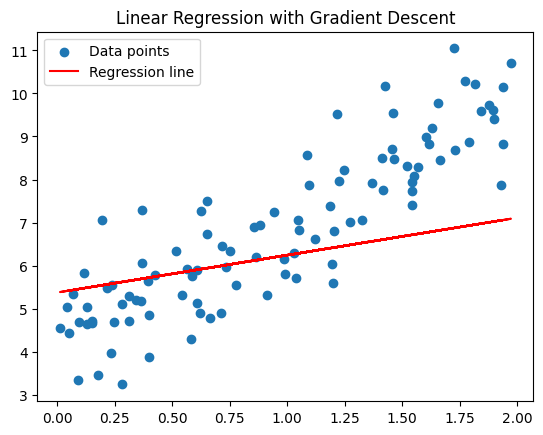

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn

fig = plt.figure()

def fit(
        X,
        y,
        eps: float = 1e-6,
        max_iter=10,
):
    size = X.shape[1]
    bias = 0
    weights = np.random.rand(size)
    lr = 1e-3

    for _ in range(max_iter):
        pred = X @ weights + bias

        if np.mean((y - pred) ** 2) < eps:
            break

        grad_w = 2 / len(y) * (X.T @ (pred - y))[:, 0] 
        grad_b = 2 / len(y) * np.sum(pred - y)   

        weights -= lr * grad_w.T
        bias -= lr * grad_b

    return weights, bias


def predict(
        X,
        weights,
        bias,
):
    return X @ weights + bias


if __name__ == '__main__':
    np.random.seed(42)
    X = 2 * np.random.rand(100, 1)
    y = 4 + 3 * X + np.random.randn(100, 1)

    weights, bias = fit(X, y)

    perd = predict(X, weights, bias)
    plt.scatter(X, y, label="Data points")
    plt.plot(X, perd, color='red', label="Regression line")
    plt.legend()
    plt.title("Linear Regression with Gradient Descent")
    plt.show()


In [9]:
perd

array([6.0256171 , 7.02560904, 6.64600404, 6.41459072, 5.64635728,
       5.64631542, 5.47638396, 6.87888695, 6.4188542 , 6.60448678,
       5.41130153, 7.05892429, 6.82034002, 5.74410553, 5.69114603,
       5.69388744, 5.90361005, 6.28632836, 6.12524745, 5.88102487,
       6.43749057, 5.61767733, 5.88261381, 6.01142311, 6.16711807,
       6.73830528, 5.72212393, 6.26806668, 6.40375395, 5.4561937 ,
       6.43001365, 5.6715326 , 5.4884774 , 7.02243508, 7.05149983,
       6.77860767, 5.90425487, 5.54509267, 6.56311152, 6.13949212,
       5.58738183, 6.23499097, 5.43525942, 6.95376693, 5.82470701,
       6.52543096, 5.91657275, 6.27819129, 6.32443085, 5.69640392,
       7.05835984, 6.72087469, 7.00614396, 6.92861319, 6.41327428,
       6.97555501, 5.52916079, 5.71571808, 5.45407088, 5.94020996,
       6.05015318, 5.84652151, 6.81390949, 5.99474684, 5.8631578 ,
       6.31746393, 5.62015983, 6.76784649, 5.50496369, 7.08838925,
       6.71586226, 5.72046108, 5.38515969, 6.79086789, 6.60237

In [1]:
import numpy as np


In [2]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

In [3]:
y_true = np.array([1, 1.1, 1.9, 1.2, 1.3])
y_pred = np.array([1.1, 1.05, 1.85, 5, 1.31])

In [4]:
mae(y_true, y_pred)

0.8019999999999999

In [6]:
mse(y_true, y_pred) ** 0.5

1.700299973534082